In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('zomato.csv', encoding='latin-1')
country = pd.read_excel('Country-Code.xlsx')

# Merge country names
df = df.merge(country, on='Country Code', how='left')

# Quick look at the data
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (9551, 22)

Columns: ['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes', 'Country']


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Phillipines
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,Phillipines
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Phillipines


In [2]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Fill missing cuisines
df['Cuisines'] = df['Cuisines'].fillna('Unknown')

# Keep only India data (most of the data is India)
india = df[df['Country'] == 'India']
print("\nIndia restaurants:", len(india))
print("Cities in India:", india['City'].nunique())

Missing values:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
Country                 0
dtype: int64

India restaurants: 8652
Cities in India: 43


C:\Users\HP\AppData\Local\Temp\ipykernel_12224\2851757750.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.values, y=city_counts.index, palette='Reds_r')


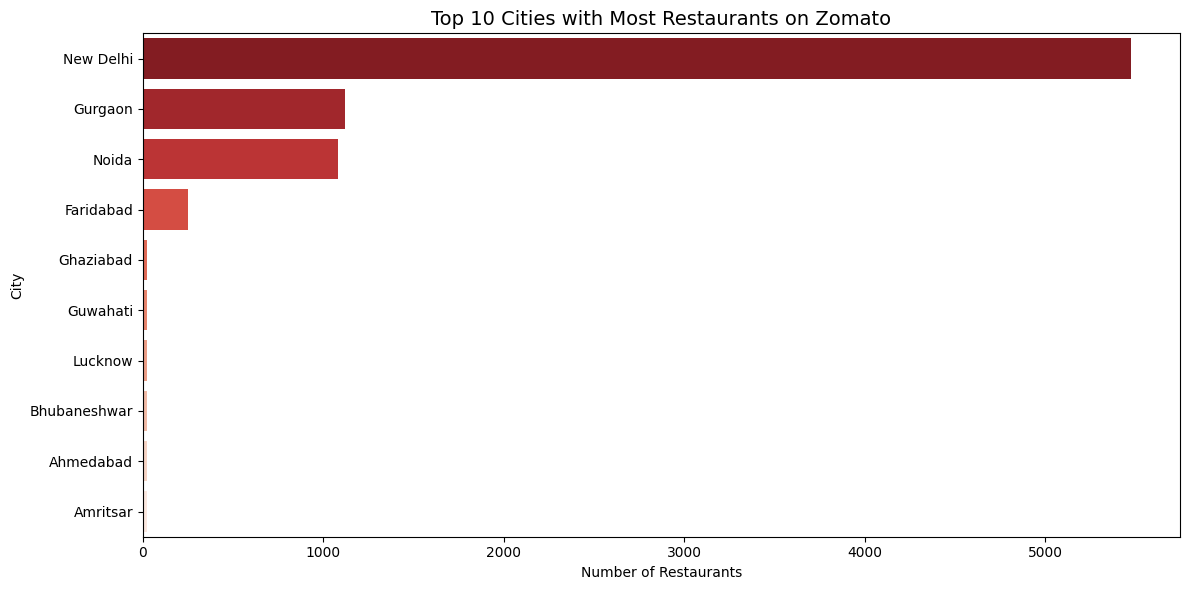

In [3]:
# Top 10 cities with most restaurants
plt.figure(figsize=(12, 6))
city_counts = india['City'].value_counts().head(10)
sns.barplot(x=city_counts.values, y=city_counts.index, palette='Reds_r')
plt.title('Top 10 Cities with Most Restaurants on Zomato', fontsize=14)
plt.xlabel('Number of Restaurants')
plt.ylabel('City')
plt.tight_layout()
plt.show()

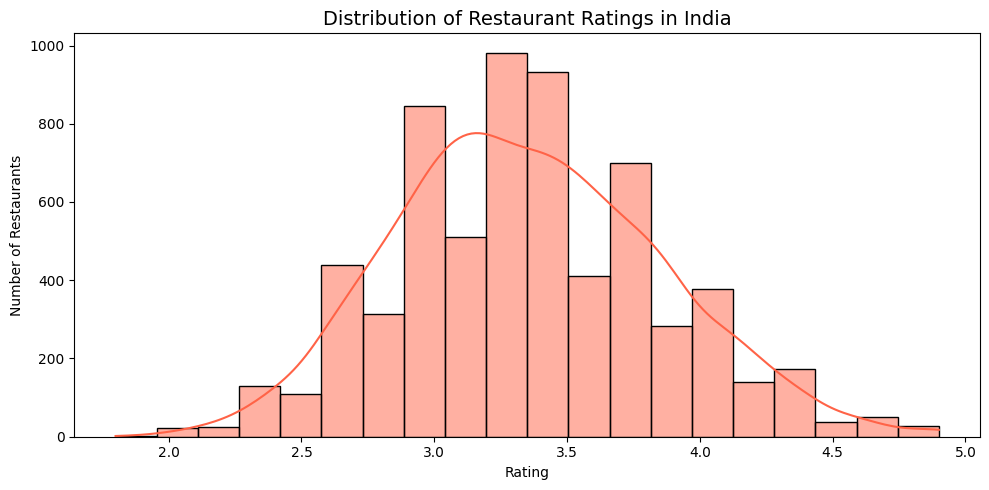

count    6513.000000
mean        3.352034
std         0.504689
min         1.800000
25%         3.000000
50%         3.300000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64


In [4]:
# How are restaurants rated?
plt.figure(figsize=(10, 5))
sns.histplot(india[india['Aggregate rating'] > 0]['Aggregate rating'], 
             bins=20, color='tomato', kde=True)
plt.title('Distribution of Restaurant Ratings in India', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()

# Rating summary
print(india[india['Aggregate rating'] > 0]['Aggregate rating'].describe())

C:\Users\HP\AppData\Local\Temp\ipykernel_12224\1038725896.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating_delivery.index, y=avg_rating_delivery.values,


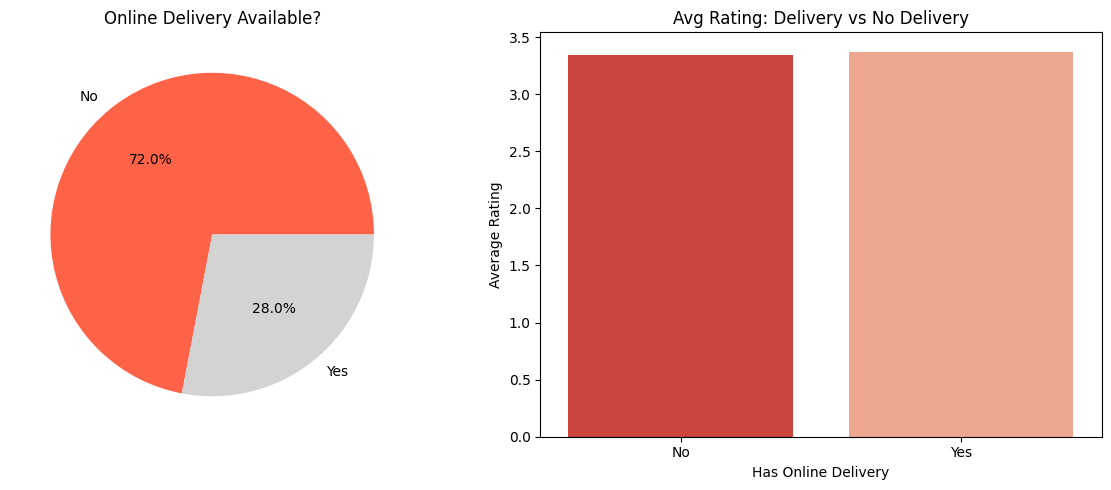

In [5]:
# Online delivery analysis
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
delivery_counts = india['Has Online delivery'].value_counts()
plt.pie(delivery_counts, labels=delivery_counts.index, 
        autopct='%1.1f%%', colors=['tomato', 'lightgray'])
plt.title('Online Delivery Available?')

plt.subplot(1, 2, 2)
avg_rating_delivery = india[india['Aggregate rating'] > 0].groupby(
    'Has Online delivery')['Aggregate rating'].mean()
sns.barplot(x=avg_rating_delivery.index, y=avg_rating_delivery.values, 
            palette='Reds_r')
plt.title('Avg Rating: Delivery vs No Delivery')
plt.xlabel('Has Online Delivery')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_12224\15676197.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cuisines, x='Count', y='Cuisine', palette='Reds_r')


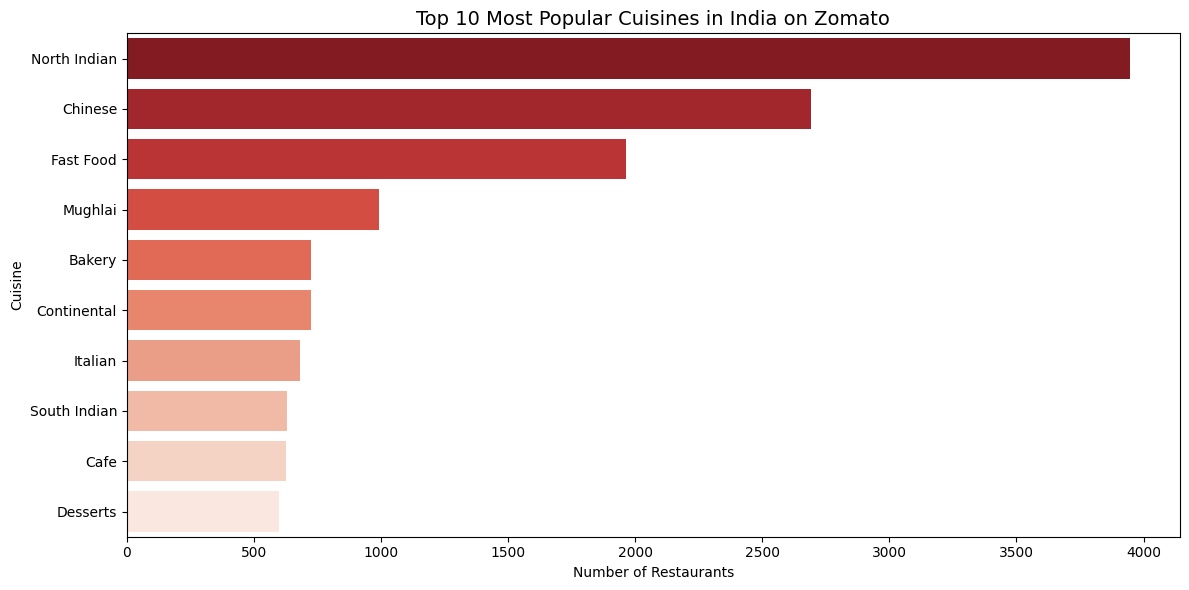

In [6]:
# Top 10 cuisines
from collections import Counter

# Split cuisines and count each one
all_cuisines = ', '.join(india['Cuisines'].dropna()).split(', ')
cuisine_counts = Counter(all_cuisines)
top_cuisines = pd.DataFrame(cuisine_counts.most_common(10), 
                             columns=['Cuisine', 'Count'])

plt.figure(figsize=(12, 6))
sns.barplot(data=top_cuisines, x='Count', y='Cuisine', palette='Reds_r')
plt.title('Top 10 Most Popular Cuisines in India on Zomato', fontsize=14)
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_12224\1884732701.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  india['Price Category'] = india['Price range'].map(price_labels)
C:\Users\HP\AppData\Local\Temp\ipykernel_12224\1884732701.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_counts.index, y=price_counts.values, palette='Reds_r')
C:\Users\HP\AppData\Local\Temp\ipykernel_12224\1884732701.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.bar

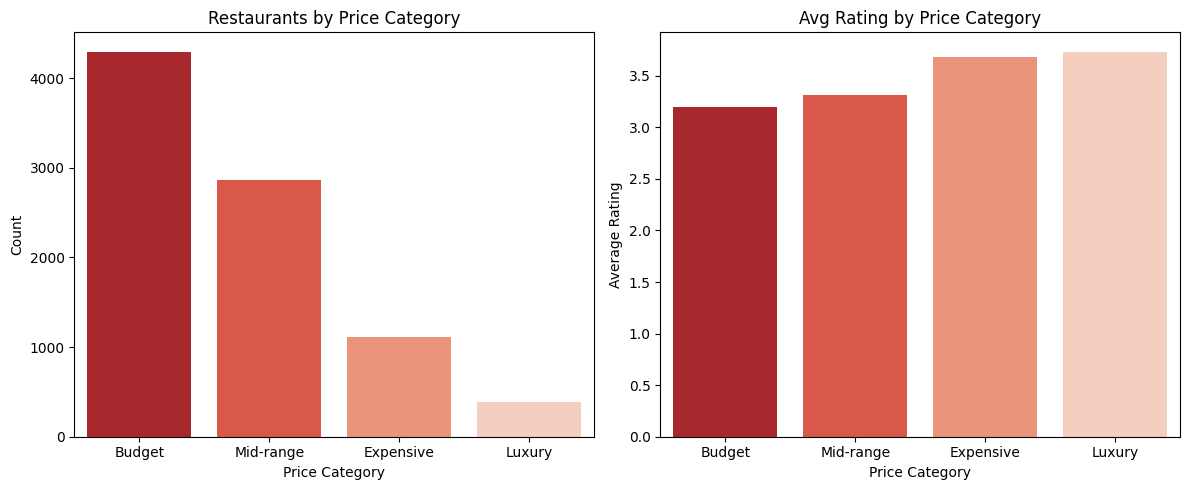

In [7]:
# Price range vs rating
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
price_labels = {1: 'Budget', 2: 'Mid-range', 3: 'Expensive', 4: 'Luxury'}
india['Price Category'] = india['Price range'].map(price_labels)
price_counts = india['Price Category'].value_counts()
sns.barplot(x=price_counts.index, y=price_counts.values, palette='Reds_r')
plt.title('Restaurants by Price Category')
plt.xlabel('Price Category')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
avg_rating_price = india[india['Aggregate rating'] > 0].groupby(
    'Price Category')['Aggregate rating'].mean().reindex(
    ['Budget', 'Mid-range', 'Expensive', 'Luxury'])
sns.barplot(x=avg_rating_price.index, y=avg_rating_price.values, palette='Reds_r')
plt.title('Avg Rating by Price Category')
plt.xlabel('Price Category')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.show()